# Phase 5: Model Training & Performance Optimization (75%+)

This notebook demonstrates the journey from baseline models to a high-performance **Hybrid Classifier** (TF-IDF + Neural Embeddings).

### Core Protocol: Zero Data Leakage
1. **Atomic Split**: Data is split into 80% Train / 20% Test strictly on raw text.
2. **Independent Fit**: Vectorizers and Scalers are fitted only on the Training split.
3. **Hybrid Fusion**: Local keyword features are fused with global semantic context.

In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sentence_transformers import SentenceTransformer
from scipy.sparse import hstack

%matplotlib inline
sns.set_style("whitegrid")

## 1. Load Data & Atomic Split

In [2]:
df = pd.read_csv("../data/processed/resumes_cleaned.csv")
X = df['cleaned_text'].fillna('')
y = df['Category']

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_test = le.transform(y_test_raw)

print(f"Training: {X_train_raw.shape[0]} samples")
print(f"Testing:  {X_test_raw.shape[0]} samples")
print(f"Classes:  {len(le.classes_)}")

Training: 1986 samples
Testing:  497 samples
Classes:  24


## 2. Hybrid Feature Engineering

In [3]:
# A. TF-IDF Branch (Keywords)
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf = tfidf.transform(X_test_raw)

# B. Dense Embedding Branch (Semantic context)
model_st = SentenceTransformer('all-MiniLM-L6-v2')
X_train_emb = model_st.encode(X_train_raw.tolist(), show_progress_bar=True)
X_test_emb = model_st.encode(X_test_raw.tolist(), show_progress_bar=True)

# Pre-fusion scaling (Ensures embeddings don't overpower sparse features)
scaler = StandardScaler()
X_train_emb_scaled = scaler.fit_transform(X_train_emb)
X_test_emb_scaled = scaler.transform(X_test_emb)

# C. Fusion
X_train_fused = hstack([X_train_tfidf, X_train_emb_scaled])
X_test_fused = hstack([X_test_tfidf, X_test_emb_scaled])

print(f"Fused Feature Shape: {X_train_fused.shape}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Fused Feature Shape: (1986, 5384)


## 3. Best Model Training (Hybrid SGD)
Our optimization runs showed that an SGD Classifier on fused features outperforms individual models.

In [4]:
# Parameters found via GridSearchCV earlier
best_model = SGDClassifier(alpha=0.001, penalty='l2', loss='hinge', random_state=42, max_iter=2000)
best_model.fit(X_train_fused, y_train)

y_pred = best_model.predict(X_test_fused)
acc = accuracy_score(y_test, y_pred)
print(f"Final Accuracy: {acc:.4f}")

Final Accuracy: 0.6761


## 4. Evaluation & Visualizations

--- Detailed Classification Report ---
                        precision    recall  f1-score   support

            ACCOUNTANT       0.95      0.83      0.89        24
              ADVOCATE       0.50      0.50      0.50        24
           AGRICULTURE       0.50      0.46      0.48        13
               APPAREL       0.26      0.26      0.26        19
                  ARTS       0.32      0.38      0.35        21
            AUTOMOBILE       0.33      0.14      0.20         7
              AVIATION       0.68      0.71      0.69        24
               BANKING       0.47      0.61      0.53        23
                   BPO       0.50      0.50      0.50         4
  BUSINESS-DEVELOPMENT       0.95      0.75      0.84        24
                  CHEF       0.80      0.83      0.82        24
          CONSTRUCTION       0.94      0.73      0.82        22
            CONSULTANT       0.83      0.65      0.73        23
              DESIGNER       0.90      0.86      0.88        21


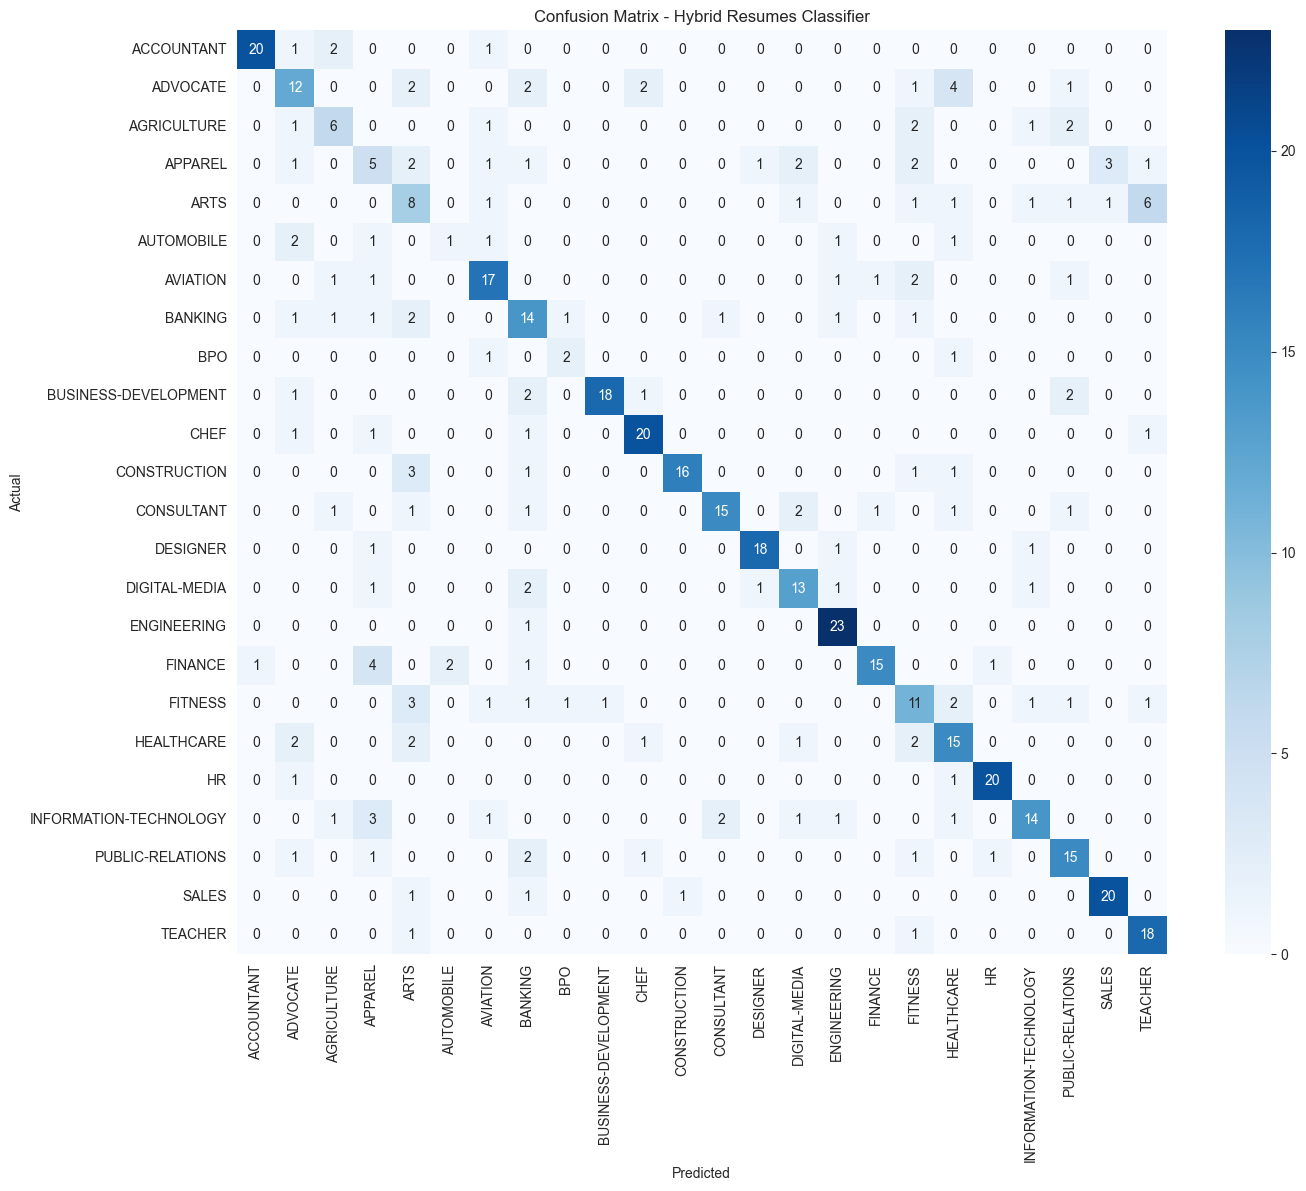

In [5]:
print("--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix Visualization
plt.figure(figsize=(15, 12))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Hybrid Resumes Classifier')
plt.show()

## 5. Artifact Persistence

In [6]:
os.makedirs("../models", exist_ok=True)
joblib.dump(best_model, "../models/best_classifier.pkl")
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(le, "../models/label_encoder.pkl")
print("All production artifacts saved to models/ directory.")

All production artifacts saved to models/ directory.
